In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

uploaded = files.upload()

df = pd.read_csv(list(uploaded.keys())[0])

print("Dataset loaded successfully!")
print(df.head())
print("\nColumns:")
print(df.columns)
print("\nShape:", df.shape)

Saving student_data.csv to student_data.csv
Dataset loaded successfully!
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]

Columns:
Index

In [ ]:
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Values:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values with median
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = df[numeric_cols].fillna(
    df[numeric_cols].median()
)

print("Data cleaning completed!")
print(df.isnull().sum())

Data cleaning completed!
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["Study_Hours"]]
y = df["Marks"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Linear Regression")
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

KeyError: "None of [Index(['Study_Hours'], dtype='object')] are in the [columns]"

In [ ]:
print(df.columns.tolist())

['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


In [ ]:
# Check dataset
print("Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (395, 33)

Column Names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

First 5 rows:


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


In [ ]:
# Remove duplicate rows
df = df.drop_duplicates()

# Fill missing numerical values
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

print("Duplicates removed and missing values handled.")
print("New shape:", df.shape)

Duplicates removed and missing values handled.
New shape: (395, 33)


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Features and target
X = df[["G1", "G2", "studytime", "failures"]]
y = df["G3"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Models
linear_model = LinearRegression()

polynomial_model = make_pipeline(
    PolynomialFeatures(degree=2),
    LinearRegression()
)

ridge_model = make_pipeline(
    StandardScaler(),
    Ridge(alpha=1.0)
)

lasso_model = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

# Train models
linear_model.fit(X_train, y_train)
polynomial_model.fit(X_train, y_train)
ridge_model.fit(X_train, y_train)
lasso_model.fit(X_train, y_train)

# Predictions
pred_linear = linear_model.predict(X_test)
pred_poly = polynomial_model.predict(X_test)
pred_ridge = ridge_model.predict(X_test)
pred_lasso = lasso_model.predict(X_test)

# Results
regression_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],
    "MSE": [
        mean_squared_error(y_test, pred_linear),
        mean_squared_error(y_test, pred_poly),
        mean_squared_error(y_test, pred_ridge),
        mean_squared_error(y_test, pred_lasso)
    ],
    "R2 Score": [
        r2_score(y_test, pred_linear),
        r2_score(y_test, pred_poly),
        r2_score(y_test, pred_ridge),
        r2_score(y_test, pred_lasso)
    ]
})

print("REGRESSION RESULTS")
display(regression_results)

REGRESSION RESULTS


,Model,MSE,R2 Score
0,Linear Regression,4.476089,0.781708
1,Polynomial Regression,4.559605,0.777635
2,Ridge Regression,4.474074,0.781806
3,Lasso Regression,4.410147,0.784924


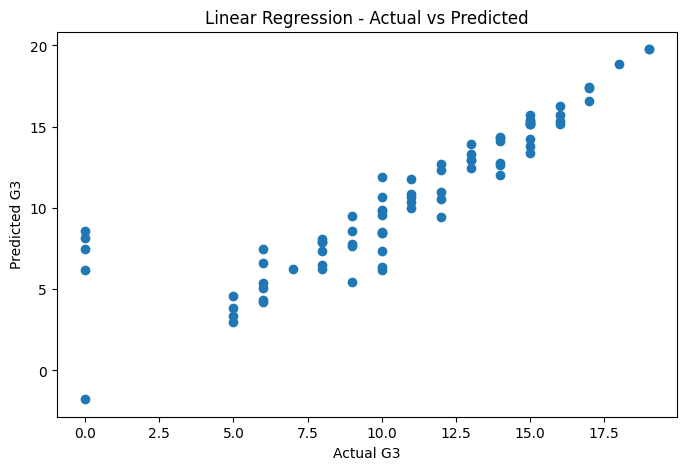

In [ ]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, pred_linear)

plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Create Pass/Fail target
df["Pass"] = (df["G3"] >= 10).astype(int)

# Features
X = df[["G1", "G2", "studytime", "failures"]]
y = df["Pass"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Logistic Regression
logistic_model = LogisticRegression(max_iter=1000)

logistic_model.fit(X_train, y_train)

pred_logistic = logistic_model.predict(X_test)

# KNN
knn_model = make_pipeline(
    StandardScaler(),
    KNeighborsClassifier(n_neighbors=5)
)

knn_model.fit(X_train, y_train)

pred_knn = knn_model.predict(X_test)

# Results
classification_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "KNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, pred_logistic),
        accuracy_score(y_test, pred_knn)
    ]
})

print("CLASSIFICATION RESULTS")
display(classification_results)

CLASSIFICATION RESULTS


,Model,Accuracy
0,Logistic Regression,0.886076
1,KNN,0.924051


In [ ]:
print("LOGISTIC REGRESSION")
print(classification_report(y_test, pred_logistic))

print("\nKNN")
print(classification_report(y_test, pred_knn))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        26
           1       0.96      0.87      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.90      0.88        79
weighted avg       0.90      0.89      0.89        79


KNN
              precision    recall  f1-score   support

           0       0.83      0.96      0.89        26
           1       0.98      0.91      0.94        53

    accuracy                           0.92        79
   macro avg       0.91      0.93      0.92        79
weighted avg       0.93      0.92      0.93        79



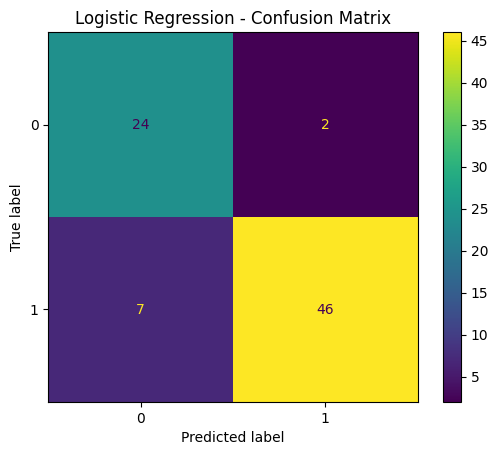

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_logistic
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

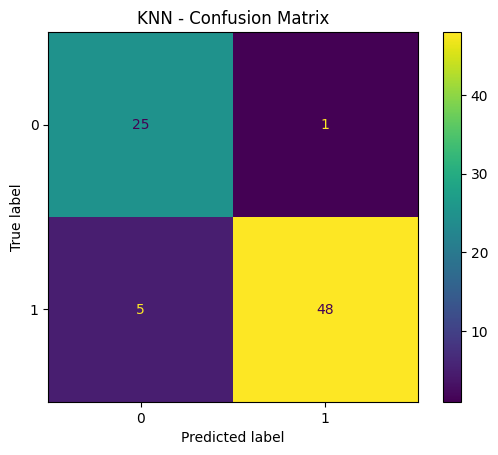

In [ ]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_knn
)

plt.title("KNN - Confusion Matrix")
plt.show()